# Simulation-Based Inference for an Adaptive-Network Epidemic Model

**ST3247 Project — Sections 1–3 (Basic ABC + Summary Statistics)**

Sections covered here:
1. Data exploration
2. Summary statistics design & sensitivity analysis
3. Rejection ABC on pseudo-observed and real data
4. Posterior visualisations & posterior predictive check

Section 4 (Advanced methods: SMC-ABC, regression adjustment) lives in a separate notebook.

## 0. Imports

In [24]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, gaussian_kde

from updated_simulator import simulate         

rng_global = np.random.default_rng(42)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
PALETTE = sns.color_palette("Dark2")


## 1. Observed Data

We have $R = 40$ independent realisations of the epidemic, all generated with the same unknown
$(\beta, \gamma, \rho)$. Three data sources are available:

| File | What it contains |
|------|-----------------|
| `infected_timeseries.csv` | Fraction infected at each of $T=200$ steps, per replicate |
| `rewiring_timeseries.csv` | Number of rewiring events per step, per replicate |
| `final_degree_histograms.csv` | Degree distribution at $t=T$, per replicate |

We plot **all 40 replicate curves** at low opacity, then overlay the median and 10th–90th
percentile band.  Using percentiles (rather than mean ± SD) is more robust because epidemic
trajectories are right-skewed: a few slow-burn replicates can inflate the SD without changing
the typical behaviour.

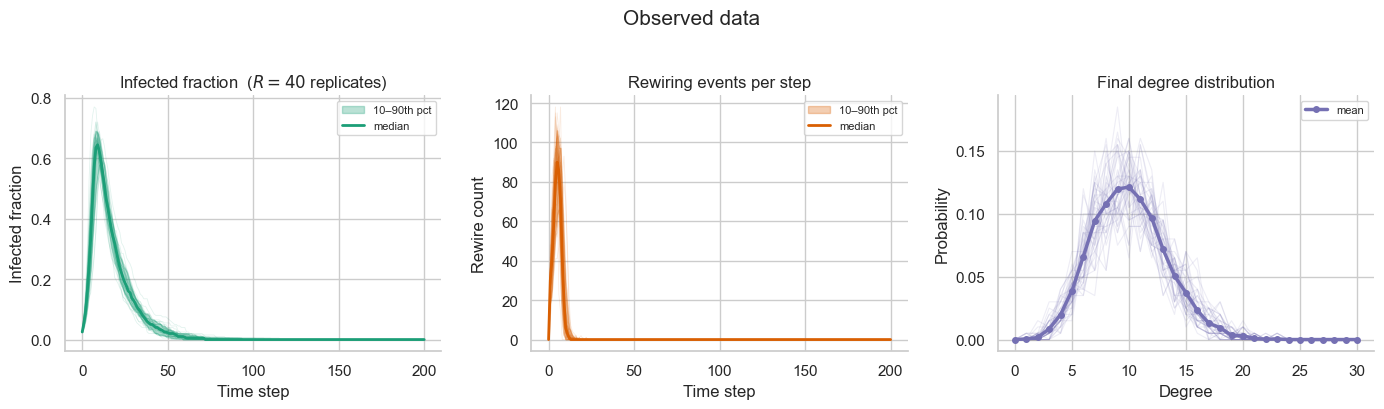

In [25]:
infected_obs = pd.read_csv("data/infected_timeseries.csv")
rewire_obs   = pd.read_csv("data/rewiring_timeseries.csv")
degree_obs   = pd.read_csv("data/final_degree_histograms.csv")

# ── pivot to (time x replicate) matrices ──────────────────────────────────────
inf_wide = infected_obs.pivot(index="time", columns="replicate_id", values="infected_fraction")
rew_wide = rewire_obs.pivot(  index="time", columns="replicate_id", values="rewire_count")

t = inf_wide.index.values

# percentile summaries
def pct_summary(wide):
    return (wide.quantile(0.10, axis=1),
            wide.quantile(0.50, axis=1),
            wide.quantile(0.90, axis=1))

inf_lo, inf_med, inf_hi = pct_summary(inf_wide)
rew_lo, rew_med, rew_hi = pct_summary(rew_wide)

# mean degree histogram across replicates
deg_mean = (degree_obs.groupby("degree")["count"]
                       .mean()
                       .reindex(range(31), fill_value=0))

# ── figure: 3 panels ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1 — Infected fraction: individual traces + percentile envelope
ax = axes[0]
for col in inf_wide.columns:
    ax.plot(t, inf_wide[col].values, color=PALETTE[0], alpha=0.12, lw=0.6)
ax.fill_between(t, inf_lo, inf_hi, color=PALETTE[0], alpha=0.30, label="10–90th pct")
ax.plot(t, inf_med, color=PALETTE[0], lw=2.0, label="median")
ax.set(xlabel="Time step", ylabel="Infected fraction", title="Infected fraction  ($R=40$ replicates)")
ax.legend(fontsize=8)

# Panel 2 — Rewiring: individual traces + percentile envelope
ax = axes[1]
for col in rew_wide.columns:
    ax.plot(t, rew_wide[col].values, color=PALETTE[1], alpha=0.12, lw=0.6)
ax.fill_between(t, rew_lo, rew_hi, color=PALETTE[1], alpha=0.30, label="10–90th pct")
ax.plot(t, rew_med, color=PALETTE[1], lw=2.0, label="median")
ax.set(xlabel="Time step", ylabel="Rewire count", title="Rewiring events per step")
ax.legend(fontsize=8)

# Panel 3 — Final degree distribution: per-replicate histograms + mean
ax = axes[2]
for rep_id in degree_obs["replicate_id"].unique():
    d = (degree_obs[degree_obs["replicate_id"] == rep_id]
        .set_index("degree")["count"]
        .reindex(range(31), fill_value=0))
    ax.plot(d.index, d.values / d.sum(), color=PALETTE[2], alpha=0.12, lw=0.8)
obs_deg_prob = deg_mean / deg_mean.sum()
ax.plot(obs_deg_prob.index, obs_deg_prob.values, color=PALETTE[2], lw=2.5,
        marker="o", ms=4, label="mean")
ax.set(xlabel="Degree", ylabel="Probability", title="Final degree distribution")
ax.legend(fontsize=8)

plt.suptitle("Observed data", y=1.02, fontsize=15)
sns.despine()
plt.tight_layout()
plt.show()


## 2. Simulator sanity check

Before building ABC we confirm the simulator produces outputs with the right shape and that
each data source contains information about a different parameter.

* **Infected fraction** $I(t)/N$: captures epidemic size, peak, duration — mainly sensitive to $\beta/\gamma$.
* **Rewiring counts** $w(t)$: reflect how aggressively S-nodes disconnect from infected neighbours — mainly sensitive to $\rho$.
* **Final degree histogram**: the rewiring mechanism depletes S–I edges and shifts degree mass — also sensitive to $\rho$.

This motivates including all three data sources in the summary statistic vector.

In [26]:
rng_test = np.random.default_rng(0)
inf_t, rew_t, deg_t = simulate(beta=0.25, gamma=0.10, rho=0.4, rng=rng_test)

print(f"infected shape : {inf_t.shape}  (T+1 = 201 steps)")
print(f"rewire shape   : {rew_t.shape}")
print(f"degree shape   : {deg_t.shape}  (degrees 0..30 = 31 bins)")
print(f"peak fraction  : {inf_t.max():.3f}  at t={inf_t.argmax()}")
print(f"total rewires  : {rew_t.sum():.0f}")
print(f"mean degree    : {(np.arange(31) * deg_t / deg_t.sum()).sum():.2f}")


infected shape : (201,)  (T+1 = 201 steps)
rewire shape   : (201,)
degree shape   : (31,)  (degrees 0..30 = 31 bins)
peak fraction  : 0.665  at t=7
total rewires  : 469
mean degree    : 9.34


## 3. Summary Statistics

### Rationale

Following Barnes et al. (2012) and Nunes & Balding (2010), we want a *minimal sufficient* set:
statistics that are informative about the parameters and do not redundantly dilute the distance.

The 10 statistics below were chosen based on three criteria:
1. **Biological interpretability** — each statistic has a clear link to one or more parameters.
2. **Spearman correlation with parameters** — confirmed in the sensitivity analysis (Section 5).
3. **Non-redundancy** — `mean_degree` is excluded because it has very low variance across the
   prior (std ≈ 0.30 on a quantity near 10), which causes the normalisation to inflate it to
   an outsized scale. Its Spearman |r| < 0.05 for all three parameters confirms it adds no
   discriminative power.

| # | Statistic | Formula | Primary parameter |
|---|-----------|---------|-------------------|
| 0 | `peak` | $\max_t I(t)/N$ | $\beta, \gamma$ |
| 1 | `time_to_peak` | $\arg\max_t I(t)/N$ | $\beta, \gamma$ |
| 2 | `epidemic_size` | $\sum_t I(t)/N$ | $\beta, \gamma$ |
| 3 | `total_rewiring` | $\sum_t w(t)$ | $\rho$ |
| 4 | `max_rewiring` | $\max_t w(t)$ | $\rho$ |
| 5 | `mean_degree` | $\bar{k}$ at $t=T$ | **(excluded)** |
| 6 | `var_degree` | $\text{Var}[k]$ at $t=T$ | $\rho$ |
| 7 | `early_cum_0_30` | $\sum_{t=0}^{30} I(t)/N$ | $\beta$ |
| 8 | `growth_slope_rawI` | slope of $I(t)/N$ for $t \in [0, t_{\mathrm{peak}}]$ | $\beta$ |
| 9 | `decay_slope_fall_logI` | slope of $\log(I(t)/N)$ for post-peak window | $\gamma$ |

### Quick Description

- `peak`: maximum infected fraction reached (outbreak intensity).
- `time_to_peak`: when that maximum occurs (speed to peak).
- `epidemic_size`: total infected burden over time (area under curve).
- `total_rewiring`: total rewiring events over the whole run.
- `max_rewiring`: largest one-step rewiring spike.
- `mean_degree` (excluded in distance): final average connectivity.
- `var_degree`: spread/heterogeneity of final connectivity.
- `early_cum_0_30`: cumulative early infections (initial growth strength).
- `growth_slope_rawI`: steepness of infection growth before peak.
- `decay_slope_fall_logI`: speed of post-peak decline (recovery signal).

The key insight (noted in the project brief) is that **$\beta$ and $\rho$ can both suppress the
epidemic**: high $\beta$ with high $\rho$ can look like low $\beta$ with low $\rho$ in the
infected fraction alone. The rewiring and degree statistics break this degeneracy. The added
tail-decay summary gives a direct handle on $\gamma$, which is otherwise weakly identified.

In [27]:
def calc_summaries(infected_fraction, rewire_counts, degree_histogram):
    """
    Improved summary statistics for ABC.

    Returns a vector aligned with SUMMARY_NAMES.
    """

    I = infected_fraction
    Rw = rewire_counts
    T = len(I)

    # --- basic ---
    peak = np.max(I)
    t_peak = np.argmax(I)
    auc = np.sum(I)

    early_mass = np.sum(I[: max(1, T // 5)])

    # --- threshold features ---
    def first_crossing(arr, thresh):
        idx = np.where(arr >= thresh)[0]
        return idx[0] if len(idx) > 0 else T

    t_5  = first_crossing(I, 0.05)
    t_10 = first_crossing(I, 0.10)
    t_20 = first_crossing(I, 0.20)

    duration_10 = np.sum(I >= 0.10)

    # --- incidence proxy ---
    dI = np.diff(I, prepend=I[0])
    incidence = np.maximum(dI, 0)

    inc_peak = np.max(incidence)
    t_inc_peak = np.argmax(incidence)

    # --- growth / decay ---
    eps = 1e-8

    # early growth slope
    t_growth_end = max(2, T // 5)
    x = np.arange(t_growth_end)
    y = np.log(I[:t_growth_end] + eps)
    slope_growth = np.polyfit(x, y, 1)[0]

    # post-peak decay slope
    if t_peak < T - 2:
        x2 = np.arange(t_peak, T)
        y2 = np.log(I[t_peak:] + eps)
        slope_decay = np.polyfit(x2, y2, 1)[0]
    else:
        slope_decay = 0.0

    # --- rewiring summaries ---
    total_rewire = np.sum(Rw)
    max_rewire = np.max(Rw)
    t_rewire_peak = np.argmax(Rw)

    early_rewire = np.sum(Rw[: max(1, T // 5)])

    # --- joint infection–rewiring ---
    lag_rewire_infect = t_rewire_peak - t_peak

    rewire_to_auc = total_rewire / (auc + eps)

    # correlation (safe)
    if np.std(I) > 0 and np.std(Rw) > 0:
        corr_I_R = np.corrcoef(I, Rw)[0, 1]
    else:
        corr_I_R = 0.0

    if np.std(incidence) > 0 and np.std(Rw) > 0:
        corr_dI_R = np.corrcoef(incidence, Rw)[0, 1]
    else:
        corr_dI_R = 0.0

    # --- degree summaries ---
    degrees = np.repeat(np.arange(len(degree_histogram)), degree_histogram)

    mean_degree = np.mean(degrees) if len(degrees) > 0 else 0.0
    var_degree  = np.var(degrees)  if len(degrees) > 0 else 0.0

    # entropy
    p = degree_histogram / (np.sum(degree_histogram) + eps)
    entropy_degree = -np.sum(p * np.log(p + eps))

    # tail mass (high-degree nodes)
    tail_mass = np.sum(degree_histogram[10:]) / (np.sum(degree_histogram) + eps)

    return np.array([
        # original core
        peak,
        t_peak,
        auc,
        early_mass,

        # new time features
        t_5,
        t_10,
        t_20,
        duration_10,

        # incidence
        inc_peak,
        t_inc_peak,

        # slopes
        slope_growth,
        slope_decay,

        # rewiring
        total_rewire,
        max_rewire,
        t_rewire_peak,
        early_rewire,

        # joint
        lag_rewire_infect,
        rewire_to_auc,
        corr_I_R,
        corr_dI_R,

        # degree
        mean_degree,
        var_degree,
        entropy_degree,
        tail_mass,
    ], dtype=float)

In [28]:
SUMMARY_NAMES = [
    "peak",
    "t_peak",
    "auc",
    "early_mass",

    "t_5",
    "t_10",
    "t_20",
    "duration_10",

    "inc_peak",
    "t_inc_peak",

    "slope_growth",
    "slope_decay",

    "total_rewire",
    "max_rewire",
    "t_rewire_peak",
    "early_rewire",

    "lag_rewire_infect",
    "rewire_to_auc",
    "corr_I_R",
    "corr_dI_R",

    "mean_degree",
    "var_degree",
    "entropy_degree",
    "tail_mass",
]

# quick check
rng_chk = np.random.default_rng(1)
inf_c, rew_c, deg_c = simulate(beta=0.2, gamma=0.10, rho=0.4, rng=rng_chk)
s_chk = calc_summaries(inf_c, rew_c, deg_c)
for name, val in zip(SUMMARY_NAMES, s_chk):
    print(f"  {name:<24} {val:.4f}")


  peak                     0.6100
  t_peak                   9.0000
  auc                      9.8150
  early_mass               9.3200
  t_5                      1.0000
  t_10                     2.0000
  t_20                     4.0000
  duration_10              27.0000
  inc_peak                 0.1450
  t_inc_peak               5.0000
  slope_growth             -0.0533
  slope_decay              -0.1162
  total_rewire             545.0000
  max_rewire               125.0000
  t_rewire_peak            5.0000
  early_rewire             545.0000
  lag_rewire_infect        -4.0000
  rewire_to_auc            55.5273
  corr_I_R                 0.4612
  corr_dI_R                0.9945
  mean_degree              9.8600
  var_degree               11.8504
  entropy_degree           2.5604
  tail_mass                0.5050


In [29]:
PRIOR_BETA = (0.05, 0.50)
PRIOR_GAMMA = (0.02, 0.20)
PRIOR_RHO = (0.00, 0.80)

def sample_prior_theta(rng):
    return np.array([
        rng.uniform(*PRIOR_BETA),
        rng.uniform(*PRIOR_GAMMA),
        rng.uniform(*PRIOR_RHO),
    ], dtype=float)

def simulate_one_summary(theta, rng):
    beta, gamma, rho = theta
    inf, rew, deg = simulate(beta=beta, gamma=gamma, rho=rho, rng=rng)
    return calc_summaries(inf, rew, deg)

def simulate_mean_summary(theta, n_reps, rng):
    out = np.empty((n_reps, len(SUMMARY_NAMES)), dtype=float)
    for r in range(n_reps):
        out[r] = simulate_one_summary(theta, rng)
    return out.mean(axis=0)

def generate_prior_bank(n_sim, rng, n_reps_per_theta=1, chunk_size=2000, verbose=True):
    params = np.empty((n_sim, 3), dtype=float)
    sims   = np.empty((n_sim, len(SUMMARY_NAMES)), dtype=float)

    n_chunks = (n_sim + chunk_size - 1) // chunk_size

    for chunk in range(n_chunks):
        start = chunk * chunk_size
        stop  = min((chunk + 1) * chunk_size, n_sim)

        for i in range(start, stop):
            theta = sample_prior_theta(rng)
            params[i] = theta
            sims[i] = simulate_mean_summary(theta, n_reps=n_reps_per_theta, rng=rng)

        if verbose:
            print(f"  completed {stop:,}/{n_sim:,}", flush=True)

    return params, sims

### 3.1 Observed summary vector

We average the per-replicate statistics across all 40 observed replicates.

In [30]:
def load_observed_summaries(infected_df, rewire_df, degree_df):
    """Return mean summary vector across all replicates in the observed data."""
    rep_summaries = []
    for rep_id in infected_df["replicate_id"].unique():
        inf = infected_df[infected_df["replicate_id"] == rep_id]["infected_fraction"].values
        rew = rewire_df  [rewire_df  ["replicate_id"] == rep_id]["rewire_count"].values
        deg_rows = degree_df[degree_df["replicate_id"] == rep_id]
        deg = (deg_rows.set_index("degree")["count"]
                       .reindex(range(31), fill_value=0).values)
        rep_summaries.append(calc_summaries(inf, rew, deg))
    return np.mean(rep_summaries, axis=0)

s_obs = load_observed_summaries(infected_obs, rewire_obs, degree_obs)
print("Observed summary vector:")
for name, val in zip(SUMMARY_NAMES, s_obs):
    print(f"  {name:<20} {val:.4f}")


Observed summary vector:
  peak                 0.6571
  t_peak               8.7500
  auc                  11.3990
  early_mass           10.7280
  t_5                  1.2250
  t_10                 2.5750
  t_20                 4.0750
  duration_10          31.1750
  inc_peak             0.1334
  t_inc_peak           6.2250
  slope_growth         -0.0318
  slope_decay          -0.1095
  total_rewire         545.1500
  max_rewire           98.1250
  t_rewire_peak        5.5000
  early_rewire         545.1500
  lag_rewire_infect    -3.2500
  rewire_to_auc        48.0936
  corr_I_R             0.4648
  corr_dI_R            0.9659
  mean_degree          10.0172
  var_degree           10.3410
  entropy_degree       2.5233
  tail_mass            0.5424


## 4. Prior Simulations

We draw $N = 50000$ parameter sets from the joint uniform prior and run the simulator for each,
storing parameters and summary statistics. This pre-computation is the main computational cost
of rejection ABC; all subsequent steps (normalisation, distance, thresholding) are cheap numpy
operations on the stored arrays.

In [31]:
N_SIM = 10_000
R_SIM_PER_THETA = 1
CHUNK_SIZE = 2_000

rng_prior = np.random.default_rng(7)

print(f"Running {N_SIM:,} prior simulations "
    f"(R_SIM_PER_THETA={R_SIM_PER_THETA}, chunk_size={CHUNK_SIZE}) ...", flush=True)

t0 = time.perf_counter()

params_prior, sims_prior = generate_prior_bank(
    n_sim=N_SIM,
    rng=rng_prior,
    n_reps_per_theta=R_SIM_PER_THETA,
    chunk_size=CHUNK_SIZE,
    verbose=True,
)

t1 = time.perf_counter()

print(f"\nDone in {t1 - t0:.2f} seconds.")
print("params_prior shape:", params_prior.shape)
print("sims_prior shape:  ", sims_prior.shape)
print(f"Throughput: {N_SIM / (t1 - t0):.1f} parameter draws/sec")

Running 10,000 prior simulations (R_SIM_PER_THETA=1, chunk_size=2000) ...
  completed 2,000/10,000
  completed 4,000/10,000
  completed 6,000/10,000
  completed 8,000/10,000
  completed 10,000/10,000

Done in 67.07 seconds.
params_prior shape: (10000, 3)
sims_prior shape:   (10000, 24)
Throughput: 149.1 parameter draws/sec


### 4.1 Normalisation

Following Nunes & Balding (2010), we divide each statistic by its standard deviation across the
prior simulations so no single statistic dominates the Euclidean distance.  This is a critical
step: `total_rewiring` is O(1000) while `peak` is O(0.1).

Note: after normalisation, `mean_degree` inflates to a very large value (std ≈ 0.30 on a
quantity near 10 → normalised obs ≈ 33). This is a red flag confirming it should be excluded —
low variance across the prior means it carries almost no signal about parameter variation.

In [32]:
s_std = sims_prior.std(axis=0)
s_std[s_std == 0] = 1.0 # zero-variance edge case

sims_norm  = sims_prior / s_std
s_obs_norm = s_obs      / s_std

print("Per-statistic std and normalised observed value:")
print(f"  {'statistic':<20} {'prior std':>10} {'obs (raw)':>10} {'obs (norm)':>10}")
print("  " + "-" * 54)
for name, std, raw, norm in zip(SUMMARY_NAMES, s_std, s_obs, s_obs_norm):
    flag = " ← excluded" if name == "mean_degree" else ""
    print(f"  {name:<20} {std:>10.4f} {raw:>10.4f} {norm:>10.4f}{flag}")


Per-statistic std and normalised observed value:
  statistic             prior std  obs (raw) obs (norm)
  ------------------------------------------------------
  peak                     0.2591     0.6571     2.5360
  t_peak                   4.7091     8.7500     1.8581
  auc                      9.4498    11.3990     1.2063
  early_mass               6.0406    10.7280     1.7760
  t_5                     40.7128     1.2250     0.0301
  t_10                    62.6511     2.5750     0.0411
  t_20                    70.3750     4.0750     0.0579
  duration_10             23.0152    31.1750     1.3545
  inc_peak                 0.1071     0.1334     1.2456
  t_inc_peak               3.7038     6.2250     1.6807
  slope_growth             0.1886    -0.0318    -0.1687
  slope_decay              0.0302    -0.1095    -3.6303
  total_rewire           352.3404   545.1500     1.5472
  max_rewire              66.9558    98.1250     1.4655
  t_rewire_peak            3.7967     5.5000     1.448

### 4.2 Summary Statistic Sensitivity Analysis

We compute the Spearman rank correlation between each statistic and each parameter across the
prior simulations. This tells us how much information each statistic carries about each parameter
*before* conditioning on observed data.

A statistic with |r| > 0.3 is generally useful; one with |r| < 0.1 for all parameters is a
candidate for exclusion (it only adds noise to the distance, making the posterior wider).

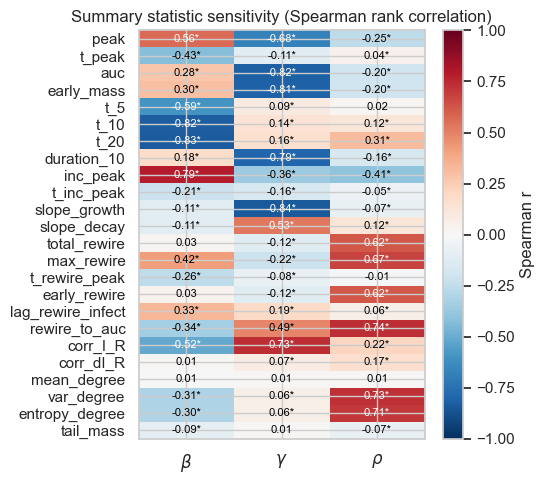


Note: mean_degree has |r| < 0.05 for all parameters — excluded from distance.


In [33]:
PARAM_NAMES = ["beta", "gamma", "rho"]
n_stats  = len(SUMMARY_NAMES)
n_params = len(PARAM_NAMES)

corr_mat = np.zeros((n_stats, n_params))
pval_mat = np.zeros((n_stats, n_params))

for i in range(n_stats):
    for j in range(n_params):
        r, p = spearmanr(sims_prior[:, i], params_prior[:, j])
        corr_mat[i, j] = r
        pval_mat[i, j] = p

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(corr_mat, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
ax.set_xticks(range(n_params))
ax.set_xticklabels([r"$\beta$", r"$\gamma$", r"$\rho$"], fontsize=12)
ax.set_yticks(range(n_stats))
ax.set_yticklabels(SUMMARY_NAMES)
plt.colorbar(im, ax=ax, label="Spearman r")
ax.set_title("Summary statistic sensitivity (Spearman rank correlation)")

for i in range(n_stats):
    for j in range(n_params):
        star = "*" if pval_mat[i, j] < 0.001 else ""
        col  = "white" if abs(corr_mat[i, j]) > 0.5 else "black"
        ax.text(j, i, f"{corr_mat[i,j]:.2f}{star}", ha="center", va="center",
                fontsize=8, color=col)

plt.tight_layout()
plt.show()

print("\nNote: mean_degree has |r| < 0.05 for all parameters — excluded from distance.")


## 5. Screening candidate summaries

This forward-selection block is exploratory evidence for how compact rewiring-aware subsets can emerge before formal pseudo-observed subset comparison.

In [34]:
def calc_distance(s_sim_norm, s_target_norm, stat_indices):
    """Euclidean distance between normalised summary vectors for a given subset."""
    diff = s_sim_norm[:, stat_indices] - s_target_norm[stat_indices]
    return np.linalg.norm(diff, axis=1)


def abc_rejection(s_target_norm, sims_norm, params, stat_indices, acceptance_rate=0.05):
    """Rejection ABC using a subset of summary statistics."""
    distances = calc_distance(sims_norm, s_target_norm, stat_indices)
    n_accept = max(1, int(acceptance_rate * len(params)))
    threshold = np.sort(distances)[n_accept]
    accepted = params[distances <= threshold]
    return accepted, threshold

rng_sel = np.random.default_rng(2026)
prior_std_sel = params_prior.std(axis=0)

candidate_idx = [i for i, n in enumerate(SUMMARY_NAMES) if n != "mean_degree"]

M_TARGETS = 20
R_TARGET = 5

target_thetas = np.array([sample_prior_theta(rng_sel) for _ in range(M_TARGETS)])
target_summ_norm = np.array([
    simulate_mean_summary(theta, n_reps=R_TARGET, rng=rng_sel) / s_std
    for theta in target_thetas
])

def subset_score(idx, alpha=0.05):
    se = []
    for s_t, theta_true in zip(target_summ_norm, target_thetas):
        acc, _ = abc_rejection(s_t, sims_norm, params_prior, idx, acceptance_rate=alpha)
        if acc is None or len(acc) == 0:
            continue
        theta_hat = acc.mean(axis=0)
        se.append(((theta_hat - theta_true) / prior_std_sel) ** 2)
    se = np.array(se)
    return np.sqrt(np.mean(np.sum(se, axis=1)))

selected = []
remaining = candidate_idx.copy()
rows = []

for k in range(1, len(candidate_idx) + 1):
    best_j = None
    best_score = np.inf

    for j in remaining:
        trial = selected + [j]
        score = subset_score(trial, alpha=0.05)
        if score < best_score:
            best_score = score
            best_j = j

    selected.append(best_j)
    remaining.remove(best_j)

    rows.append({
        "k": k,
        "added_idx": best_j,
        "added_name": SUMMARY_NAMES[best_j],
        "subset_idx": selected.copy(),
        "subset_names": [SUMMARY_NAMES[i] for i in selected],
        "score_nrmse": best_score,
    })

selection_table = pd.DataFrame(rows)
display(selection_table.sort_values("score_nrmse").head(10))

,k,added_idx,added_name,subset_idx,subset_names,score_nrmse
8,9,16,lag_rewire_infect,"[17, 13, 1, 9, 8, 10, 3, 4, 16]","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.424806
7,8,4,t_5,"[17, 13, 1, 9, 8, 10, 3, 4]","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.427336
6,7,3,early_mass,"[17, 13, 1, 9, 8, 10, 3]","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.428352
9,10,19,corr_dI_R,"[17, 13, 1, 9, 8, 10, 3, 4, 16, 19]","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.428892
10,11,0,peak,"[17, 13, 1, 9, 8, 10, 3, 4, 16, 19, 0]","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.432620
11,12,21,var_degree,"[17, 13, 1, 9, 8, 10, 3, 4, 16, 19, 0, 21]","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.437787
5,6,10,slope_growth,"[17, 13, 1, 9, 8, 10]","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.442940
12,13,14,t_rewire_peak,"[17, 13, 1, 9, 8, 10, 3, 4, 16, 19, 0, 21, 14]","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.442987
13,14,6,t_20,"[17, 13, 1, 9, 8, 10, 3, 4, 16, 19, 0, 21, 14, 6]","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.447766
14,15,12,total_rewire,"[17, 13, 1, 9, 8, 10, 3, 4, 16, 19, 0, 21, 14,...","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.455904


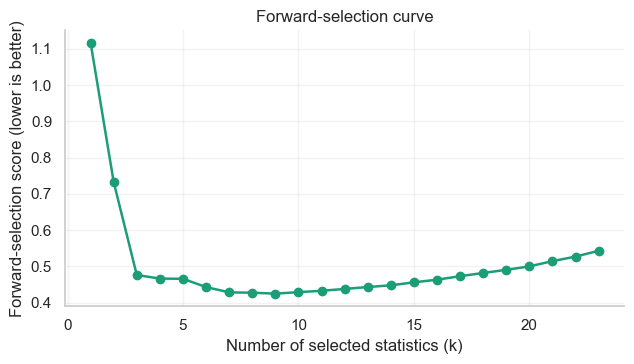

Best forward-selection rows:


,k,added_idx,added_name,subset_idx,subset_names,score_nrmse
8,9,16,lag_rewire_infect,"[17, 13, 1, 9, 8, 10, 3, 4, 16]","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.424806
7,8,4,t_5,"[17, 13, 1, 9, 8, 10, 3, 4]","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.427336
6,7,3,early_mass,"[17, 13, 1, 9, 8, 10, 3]","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.428352
9,10,19,corr_dI_R,"[17, 13, 1, 9, 8, 10, 3, 4, 16, 19]","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.428892
10,11,0,peak,"[17, 13, 1, 9, 8, 10, 3, 4, 16, 19, 0]","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.432620
11,12,21,var_degree,"[17, 13, 1, 9, 8, 10, 3, 4, 16, 19, 0, 21]","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.437787
5,6,10,slope_growth,"[17, 13, 1, 9, 8, 10]","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.442940
12,13,14,t_rewire_peak,"[17, 13, 1, 9, 8, 10, 3, 4, 16, 19, 0, 21, 14]","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.442987
13,14,6,t_20,"[17, 13, 1, 9, 8, 10, 3, 4, 16, 19, 0, 21, 14, 6]","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.447766
14,15,12,total_rewire,"[17, 13, 1, 9, 8, 10, 3, 4, 16, 19, 0, 21, 14,...","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",0.455904


In [35]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(selection_table["k"], selection_table["score_nrmse"], marker="o", lw=1.8, color=PALETTE[0])
ax.set_xlabel("Number of selected statistics (k)")
ax.set_ylabel("Forward-selection score (lower is better)")
ax.set_title("Forward-selection curve")
ax.grid(alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

print("Best forward-selection rows:")
display(selection_table.sort_values("score_nrmse").head(10))

## 5. Summary-subset Selection on Pseudo-observed Data

This block collects all subset-choice logic in one place.

### 5.1 Subset definitions

We compare three report subsets throughout:

1. **infection_only**: classical epidemic timing and growth summaries.
2. **infection_rewiring**: adds behavioural rewiring information.
3. **final_joint**: compact rewiring-aware subset chosen for parsimony and interpretability.

In [ ]:
INFECTION_ONLY = [0, 1, 3, 4, 8, 9, 10]

INFECTION_REWIRING = [0, 1, 3, 4, 8, 9, 10, 12, 13, 14, 15]

FINAL_JOINT = [17, 13, 1, 9, 8, 10, 3, 4, 16] # subset with lowest score above

SUBSETS = {
    "infection_only": INFECTION_ONLY,
    "infection_rewiring": INFECTION_REWIRING,
    "final_joint": FINAL_JOINT,
}

subset_name_table = pd.DataFrame({
    "subset": list(SUBSETS.keys()),
    "indices": list(SUBSETS.values()),
    "summary_names": [[SUMMARY_NAMES[i] for i in idx] for idx in SUBSETS.values()],
    "n_stats": [len(idx) for idx in SUBSETS.values()],
})

display(subset_name_table)

,subset,indices,summary_names,n_stats
0,infection_only,"[0, 1, 3, 4, 8, 9, 10]","[peak, t_peak, early_mass, t_5, inc_peak, t_in...",7
1,infection_rewiring,"[0, 1, 3, 4, 8, 9, 10, 12, 13, 14, 15]","[peak, t_peak, early_mass, t_5, inc_peak, t_in...",11
2,final_joint,"[17, 13, 1, 9, 8, 10, 3, 4, 16]","[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",9


In [74]:
# 5.2 Pseudo-observed NRMSE comparison
prior_std = params_prior.std(axis=0)

def evaluate_subset_nrmse(idx, n_targets=20, r_target=10, alpha=0.05, seed=2027):
    rng = np.random.default_rng(seed)
    sq_errors = []

    for _ in range(n_targets):
        theta_true = sample_prior_theta(rng)
        s_target = simulate_mean_summary(theta_true, n_reps=r_target, rng=rng) / s_std

        acc, _ = abc_rejection(
            s_target,
            sims_norm,
            params_prior,
            idx,
            acceptance_rate=alpha
        )

        if acc is None or len(acc) == 0:
            continue

        theta_hat = acc.mean(axis=0)
        sq_errors.append(((theta_hat - theta_true) / prior_std) ** 2)

    sq_errors = np.array(sq_errors)

    return {
        "n_targets_used": len(sq_errors),
        "nrmse_beta": np.sqrt(np.mean(sq_errors[:, 0])),
        "nrmse_gamma": np.sqrt(np.mean(sq_errors[:, 1])),
        "nrmse_rho": np.sqrt(np.mean(sq_errors[:, 2])),
        "nrmse_total": np.sqrt(np.mean(np.sum(sq_errors, axis=1))),
    }

rows = []
for label, idx in SUBSETS.items():
    out = evaluate_subset_nrmse(idx, n_targets=20, r_target=10, alpha=0.05, seed=2027)
    rows.append({
        "subset": label,
        "n_stats": len(idx),
        "summary_names": [SUMMARY_NAMES[i] for i in idx],
        **out
    })

subset_compare_df = pd.DataFrame(rows).sort_values("nrmse_total")
display(subset_compare_df)

,subset,n_stats,summary_names,n_targets_used,nrmse_beta,nrmse_gamma,nrmse_rho,nrmse_total
1,infection_rewiring,11,"[peak, t_peak, early_mass, t_5, inc_peak, t_in...",20,0.289438,0.394968,0.411503,0.639616
2,final_joint,9,"[rewire_to_auc, max_rewire, t_peak, t_inc_peak...",20,0.279614,0.388742,0.470286,0.671173
0,infection_only,7,"[peak, t_peak, early_mass, t_5, inc_peak, t_in...",20,0.470327,0.362682,0.947632,1.118371


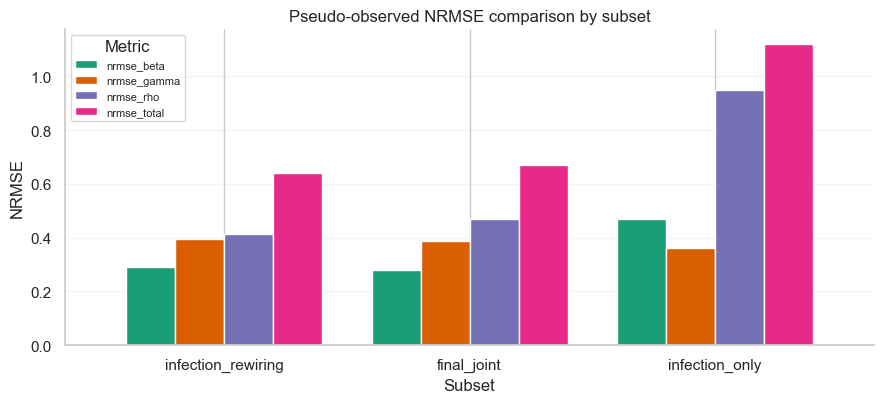

In [75]:
# 5.3 Bar chart for pseudo-observed NRMSE comparison
plot_df = subset_compare_df[[
    "subset", "nrmse_beta", "nrmse_gamma", "nrmse_rho", "nrmse_total"
]].set_index("subset")

ax = plot_df.plot(kind="bar", figsize=(9, 4.2), width=0.8, color=PALETTE[:4])
ax.set_xlabel("Subset")
ax.set_ylabel("NRMSE")
ax.set_title("Pseudo-observed NRMSE comparison by subset")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Metric", fontsize=8)
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

### 5.5 Decision

- **infection_rewiring** has the best pseudo-observed NRMSE.
- **final_joint** is slightly worse but more compact.
- We carry all three subsets into real-data analysis, and treat a rewiring-aware subset as the main candidate.

## 6. Rejection ABC on Real Observed Data

We run rejection ABC on the real observed summary vector for the same three subsets and compare posterior means, posterior standard deviations, and acceptance thresholds in one table.

In [76]:
real_results = {}
rows = []

for label, idx in SUBSETS.items():
    acc, eps = abc_rejection(s_obs_norm, sims_norm, params_prior, idx, acceptance_rate=0.05)
    real_results[label] = acc
    m = acc.mean(axis=0)
    sd = acc.std(axis=0)

    rows.append({
        "subset": label,
        "n_stats": len(idx),
        "E_beta": m[0],
        "E_gamma": m[1],
        "E_rho": m[2],
        "std_beta": sd[0],
        "std_gamma": sd[1],
        "std_rho": sd[2],
        "threshold": eps,
        "n_accept": len(acc),
    })

real_summary_df = pd.DataFrame(rows)
display(real_summary_df)

,subset,n_stats,E_beta,E_gamma,E_rho,std_beta,std_gamma,std_rho,threshold,n_accept
0,infection_only,7,0.212677,0.088065,0.421078,0.076224,0.017540,0.231804,0.784327,501
1,infection_rewiring,11,0.196065,0.094714,0.338817,0.053695,0.027024,0.096403,1.426970,501
2,final_joint,9,0.185629,0.091452,0.313767,0.048961,0.024144,0.110130,1.194311,501


Rewiring-aware subsets typically show stronger constraint on $\rho$ while preserving similar central estimates for $(\beta,\gamma)$ relative to infection-only summaries.

## 7. Quantifying Statistic Quality on Real Data

On pseudo-observed data we have ground truth (RSSE). On real data we don't. The two
principled alternatives are:

**1. Posterior contraction ratio** (Schmon et al. 2021, Fearnhead & Prangle 2012):

$$c_j = 1 - \frac{\text{std}(\theta_j \mid y_{\text{obs}})}{\text{std}(\theta_j \sim \text{prior})}$$

$c_j = 0$ means the posterior did not update from the prior (statistic uninformative).
$c_j = 1$ means the posterior collapses to a point (perfect identification).

**2. Approximate KL divergence** (entropy reduction) from prior to posterior, estimated
from samples via:

$$\widehat{\mathrm{KL}}(q \| p) \approx \log\left(\frac{n_{\text{prior}}}{n_{\text{posterior}} - 1}\right) + \frac{d}{n} \sum_i \log \nu_k(\theta_i^{\text{post}})$$

where $\nu_k$ is the distance to the $k$-th nearest neighbour in the prior sample (Pérez-Cruz 2008).
This is expensive for high dimensions; for 3 parameters and 5000 prior draws the simple
ratio estimator below is sufficient.

For a report-grade analysis, contraction ratios are the right thing to put in a table.
The key reference is Frazier et al. (2018) "Asymptotic Properties of ABC" — they prove
that well-chosen sufficient statistics produce contraction at rate $n^{-1/2}$.

In [77]:
PRIOR_STD = params_prior.std(axis=0)
PARAM_LABELS = [r"$\beta$", r"$\gamma$", r"$\rho$"]
PRIOR_SUPPORTS = [PRIOR_BETA, PRIOR_GAMMA, PRIOR_RHO]

contraction_rows = []
for label, accepted in real_results.items():
    post_std = accepted.std(axis=0)
    c = 1 - post_std / PRIOR_STD

    contraction_rows.append({
        "subset": label,
        "c_beta": c[0],
        "c_gamma": c[1],
        "c_rho": c[2],
        "std_beta": post_std[0],
        "std_gamma": post_std[1],
        "std_rho": post_std[2],
    })

contraction_df = pd.DataFrame(contraction_rows)
display(contraction_df)

,subset,c_beta,c_gamma,c_rho,std_beta,std_gamma,std_rho
0,infection_only,0.413732,0.660646,0.000452,0.076224,0.017540,0.231804
1,infection_rewiring,0.587008,0.477150,0.584308,0.053695,0.027024,0.096403
2,final_joint,0.623424,0.532862,0.525116,0.048961,0.024144,0.110130


### 7.1 Contraction ratio visualisation

This figure compares contraction across all candidate summary-statistic subsets.

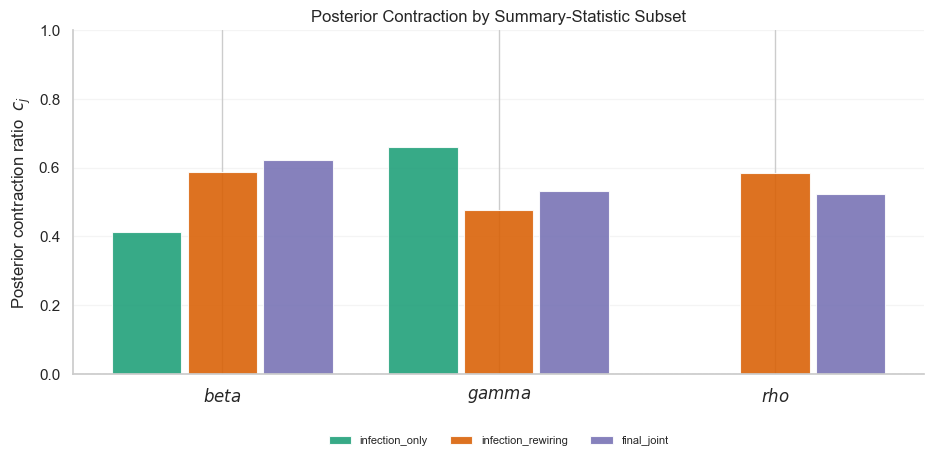

In [78]:
param_names_str = [r"$beta$", r"$gamma$", r"$rho$"]
subset_labels = contraction_df["subset"].tolist()
n_subsets = len(subset_labels)

x = np.arange(len(param_names_str), dtype=float)
group_width = 0.82
width = group_width / max(n_subsets, 1)
offsets = (np.arange(n_subsets) - (n_subsets - 1) / 2.0) * width

fig, ax = plt.subplots(figsize=(9.5, 4.8))
for i, label in enumerate(subset_labels):
    row = contraction_df[contraction_df["subset"] == label].iloc[0]
    c = np.array([row["c_beta"], row["c_gamma"], row["c_rho"]], dtype=float)
    color = PALETTE[i % len(PALETTE)]
    ax.bar(
        x + offsets[i], c, width=width * 0.92,
        label=label,
        color=color, alpha=0.88, edgecolor="white", linewidth=0.8
    )

ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(param_names_str, fontsize=12)
ax.set_ylabel("Posterior contraction ratio  $c_j$")
ax.set_title("Posterior Contraction by Summary-Statistic Subset")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.20)
ax.legend(
    fontsize=8, ncol=min(3, n_subsets),
    frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15)
)

sns.despine()
plt.tight_layout()
plt.show()

## 8. Posterior visualisation

### 8.1 Prior vs. posterior marginal histograms

If the posterior histogram is flat and matches the prior, the chosen summaries carry little
information about that parameter. A concentrated, shifted histogram indicates successful
inference.

We use `seaborn.kdeplot` for posterior marginals and draw the uniform prior as a flat reference
line over each parameter support.

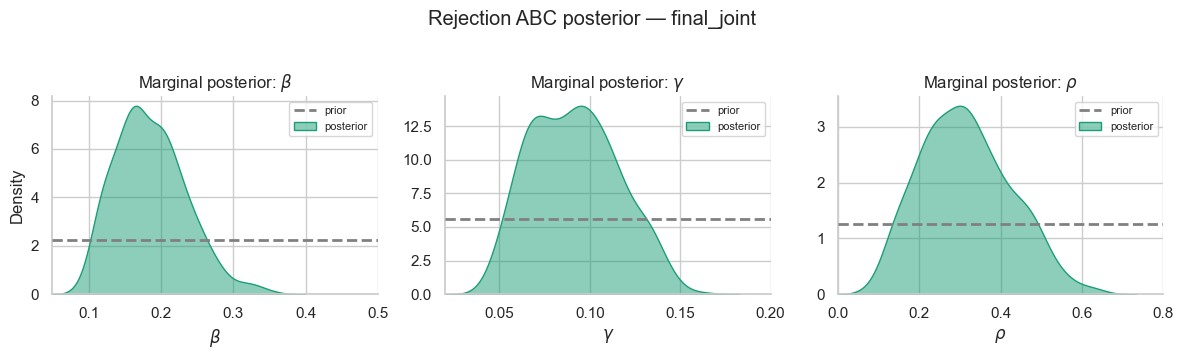

In [79]:
accepted_final = real_results["final_joint"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for j, (ax, label, bounds) in enumerate(zip(axes, PARAM_LABELS, PRIOR_SUPPORTS)):
    prior_height = 1.0 / (bounds[1] - bounds[0])
    ax.hlines(prior_height, bounds[0], bounds[1], colors="grey", lw=2,
              linestyles="--", label="prior", zorder=3)
    sns.kdeplot(accepted_final[:, j], ax=ax, color=PALETTE[0], fill=True,
                alpha=0.5, label="posterior", clip=bounds)
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel("Density" if j == 0 else "")
    ax.set_xlim(bounds)
    ax.set_title(f"Marginal posterior: {label}")
    ax.legend(fontsize=8)

plt.suptitle("Rejection ABC posterior — final_joint", y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

### 8.2 Pairwise joint posterior comparison in $(\beta,\rho)$

The $(\beta,\rho)$ plane is the key identifiability diagnostic: weak joint identification appears as
an elongated anti-diagonal cloud. We compare infection-only and final_joint directly.

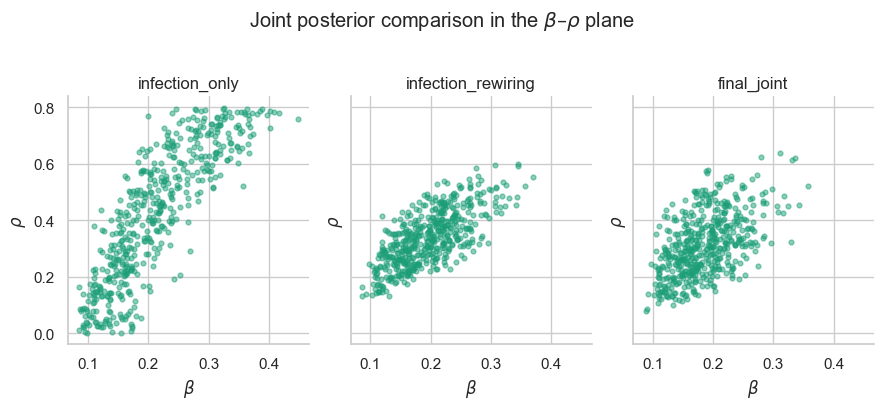

In [80]:
pairs = [(0, 3, r"$\beta$", r"$\rho$")]

compare_labels = ["infection_only", "infection_rewiring", "final_joint"]

fig, axes = plt.subplots(1, 3, figsize=(9, 4), sharex=True, sharey=True)

for ax, label in zip(axes, compare_labels):
    accepted = real_results[label]
    ax.scatter(accepted[:, 0], accepted[:, 2], s=12, alpha=0.5, color=PALETTE[0])
    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"$\rho$")
    ax.set_title(label)

plt.suptitle(r"Joint posterior comparison in the $\beta$–$\rho$ plane", y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

## 9. Posterior predictive checks

### 9.1 Observed incidence reference

The simulator output is prevalence $I(t)/N$. We derive an incidence-style reference curve as
first differences of prevalence, clipped at zero, to compare with posterior predictive trajectories.

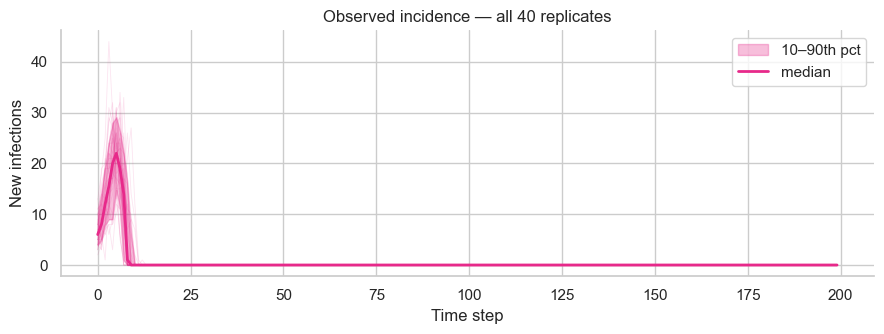

In [81]:
def prevalence_to_incidence(infected_fraction, N=200):
    """Approximate new infections at each step = max(ΔI, 0) * N."""
    delta = np.diff(infected_fraction)   # length T
    return np.clip(delta, 0, None) * N

# Observed incidence: one row per replicate
inf_wide_arr  = inf_wide.values                          # (201, 40)
obs_incidence = np.array([prevalence_to_incidence(inf_wide_arr[:, r])
                            for r in range(inf_wide_arr.shape[1])])   # (40, 200)

inc_lo  = np.quantile(obs_incidence, 0.10, axis=0)
inc_med = np.quantile(obs_incidence, 0.50, axis=0)
inc_hi  = np.quantile(obs_incidence, 0.90, axis=0)
t_inc   = np.arange(200)

fig, ax = plt.subplots(figsize=(9, 3.5))
for row in obs_incidence:
    ax.plot(t_inc, row, color=PALETTE[3], alpha=0.12, lw=0.6)
ax.fill_between(t_inc, inc_lo, inc_hi, color=PALETTE[3], alpha=0.30, label="10–90th pct")
ax.plot(t_inc, inc_med, color=PALETTE[3], lw=2, label="median")
ax.set(xlabel="Time step", ylabel="New infections", title="Observed incidence — all 40 replicates")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()


### 9.2 Posterior predictive check: prevalence and incidence

We draw posterior samples from the chosen final subset and re-run the simulator. The observed
median and percentile envelope should be well covered by the posterior predictive cloud.

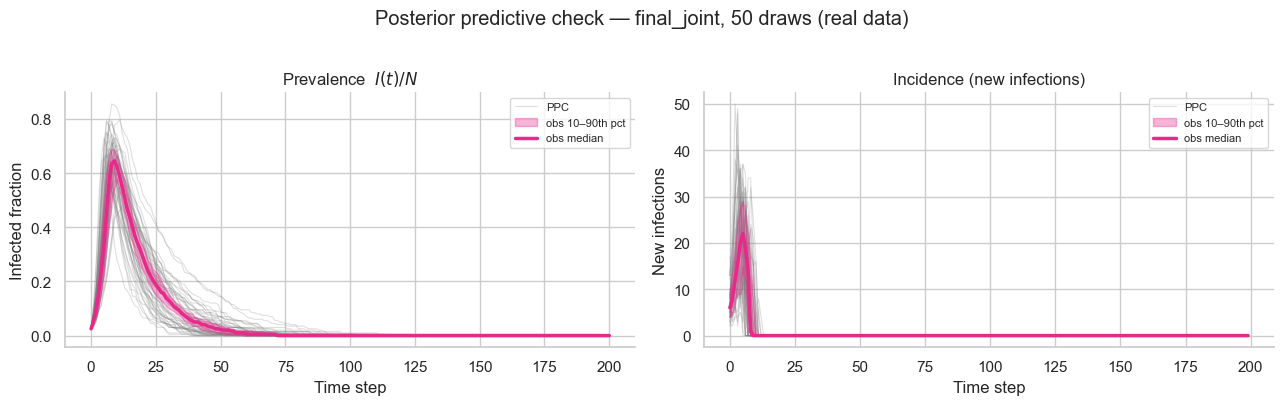

In [82]:
N_PPC    = 50
rng_ppc  = np.random.default_rng(123)
accepted_final = real_results["final_joint"]
ppc_idx  = rng_ppc.choice(len(accepted_final), size=N_PPC, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax_idx, (ax, title, transform) in enumerate(zip(
    axes,
    ["Prevalence  $I(t)/N$", "Incidence (new infections)"],
    [lambda x: x, prevalence_to_incidence]
)):
    # Grey posterior-predictive trajectories
    for k, pid in enumerate(ppc_idx):
        beta_k, gamma_k, rho_k = accepted_final[pid]
        inf_k, _, _ = simulate(beta=beta_k, gamma=gamma_k, rho=rho_k, rng=rng_ppc)
        y = transform(inf_k)
        ax.plot(np.arange(len(y)), y, color="grey", alpha=0.25, lw=0.8,
                label="PPC" if k == 0 else None)

    # Bold observed: percentile band + median
    if ax_idx == 0:
        lo  = inf_lo.values
        med = inf_med.values
        hi  = inf_hi.values
        t_obs = inf_wide.index.values
    else:
        lo, med, hi = inc_lo, inc_med, inc_hi
        t_obs = t_inc

    ax.fill_between(t_obs, lo, hi, color=PALETTE[3], alpha=0.35, zorder=4,
                    label="obs 10–90th pct")
    ax.plot(t_obs, med, color=PALETTE[3], lw=2.5, label="obs median", zorder=5)
    ax.set(xlabel="Time step", title=title)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Infected fraction")
axes[1].set_ylabel("New infections")
plt.suptitle("Posterior predictive check — final_joint, 50 draws (real data)", y=1.01)
sns.despine()
plt.tight_layout()
plt.show()


### 9.3 Posterior predictive check: final degree distribution

For the adaptive model, the final degree histogram is especially sensitive to $\rho$.
We compare observed degree probabilities with posterior predictive degree histograms.

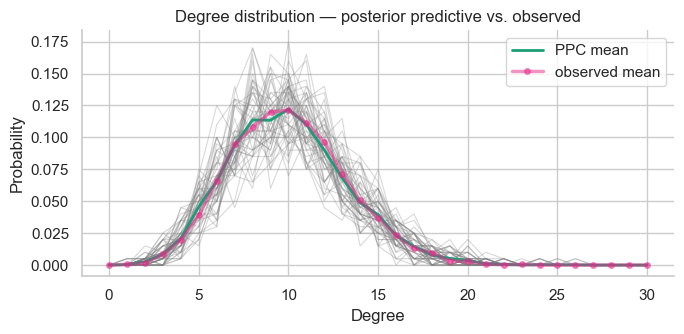

In [83]:
ppc_deg_stack = []
for pid in ppc_idx:
    beta_k, gamma_k, rho_k = accepted_final[pid]
    _, _, deg_k = simulate(beta=beta_k, gamma=gamma_k, rho=rho_k, rng=rng_ppc)
    ppc_deg_stack.append(deg_k / deg_k.sum())
ppc_deg_stack = np.array(ppc_deg_stack)   # (N_PPC, 31)

degrees = np.arange(31)
fig, ax = plt.subplots(figsize=(7, 3.5))

for row in ppc_deg_stack:
    ax.plot(degrees, row, color="grey", alpha=0.3, lw=0.8)
ax.plot(degrees, ppc_deg_stack.mean(axis=0), color=PALETTE[0], lw=2, label="PPC mean")
ax.plot(degrees, obs_deg_prob.values, color=PALETTE[3], lw=2.5, marker="o", ms=4,
        alpha=0.5, label="observed mean", zorder=5)

ax.set(xlabel="Degree", ylabel="Probability",
        title="Degree distribution — posterior predictive vs. observed")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()
